#  Analyse Exploratoire des Accidents de la Route aux États-Unis (EDA)

## Objectifs
Cette phase vise à :
- Comprendre la structure globale des accidents de la route
- Identifier des tendances temporelles et géographiques
- Explorer les relations entre la gravité des accidents, le temps, la météo et les infrastructures routières
- Préparer le terrain pour les analyses statistiques avancées

Les données ont été préalablement nettoyées et imputées afin de garantir la fiabilité des analyses.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


### Aperçu général

In [3]:
df= pd.read_csv("us.csv")

In [4]:
df.shape


(500000, 46)

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     500000 non-null  object 
 1   Source                 500000 non-null  object 
 2   Severity               500000 non-null  int64  
 3   Start_Time             500000 non-null  object 
 4   End_Time               500000 non-null  object 
 5   Start_Lat              500000 non-null  float64
 6   Start_Lng              500000 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           500000 non-null  float64
 10  Description            500000 non-null  object 
 11  Street                 500000 non-null  object 
 12  City                   499978 non-null  object 
 13  County                 500000 non-null  object 
 14  State                  500000 non-nu

In [6]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


### Résumé des variables numériques

In [7]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,500000,500000,A-1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source,500000,2,Source2,495498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Severity,500000.0,NaN,NaN,NaN,2.37469,0.486796,1.0,2.0,2.0,3.0,4.0
Start_Time,500000,492500,2016-04-10 08:59:26,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
End_Time,500000,488976,2016-10-14 19:50:00,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Start_Lat,500000.0,NaN,NaN,NaN,35.929426,5.032482,25.433098,32.811352,34.24725,40.134354,48.19997
Start_Lng,500000.0,NaN,NaN,NaN,-97.590381,18.280944,-123.813927,-118.096634,-95.543968,-81.56575,-70.571518
End_Lat,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
End_Lng,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance(mi),500000.0,NaN,NaN,NaN,0.065294,0.782881,0.0,0.0,0.01,0.01,90.370003


### Valeurs manquantes

In [19]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing": missing, "Percent": missing_percent})
print(missing_df.sort_values("Percent", ascending=False))

                       Missing   Percent
End_Lng                 500000  100.0000
End_Lat                 500000  100.0000
Precipitation(in)       448054   89.6108
Wind_Chill(F)           437641   87.5282
Wind_Speed(mph)          89040   17.8080
Visibility(mi)           10539    2.1078
Weather_Condition        10185    2.0370
Humidity(%)               7915    1.5830
Temperature(F)            7250    1.4500
Pressure(in)              5739    1.1478
Wind_Direction            4147    0.8294
Weather_Timestamp         4115    0.8230
Airport_Code                60    0.0120
Timezone                    58    0.0116
Zipcode                     58    0.0116
Nautical_Twilight           22    0.0044
Civil_Twilight              22    0.0044
City                        22    0.0044
Astronomical_Twilight       22    0.0044
Sunrise_Sunset              22    0.0044
Description                  0    0.0000
Street                       0    0.0000
Source                       0    0.0000
ID              

### Les doublons

In [10]:
df.duplicated().sum()
df.duplicated(subset=["ID"]).sum()


np.int64(0)

### Data Types

In [11]:
df.dtypes.value_counts()


object     20
bool       13
float64    12
int64       1
Name: count, dtype: int64

### Valeurs aberrantes


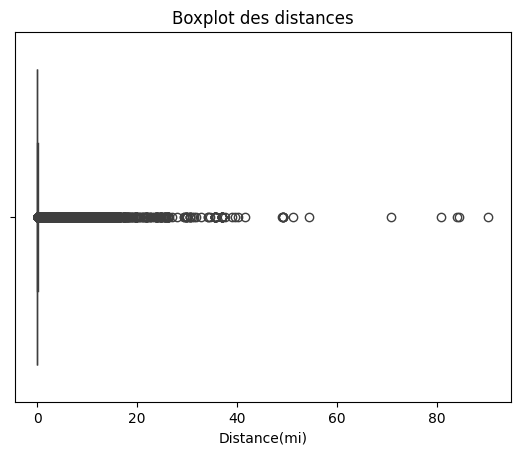

In [7]:
sns.boxplot(x=df['Distance(mi)'])
plt.title("Boxplot des distances")
plt.show()

### Distribution des variables importantes


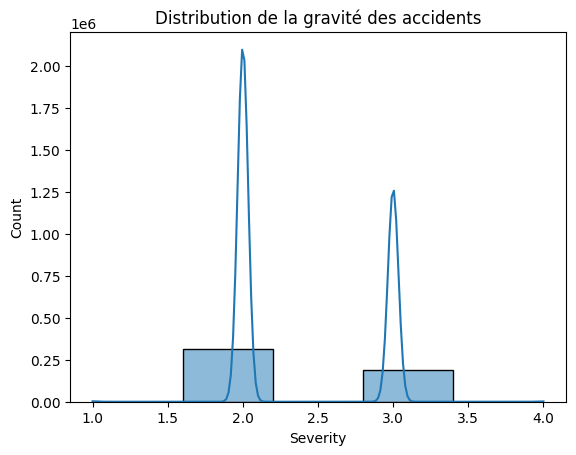

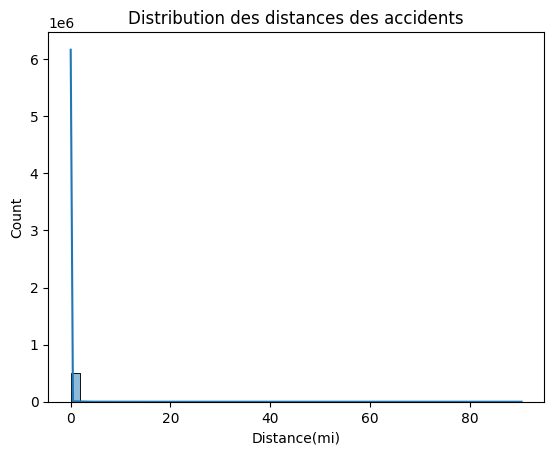

In [5]:
sns.histplot(df['Severity'], bins=5, kde=True)
plt.title("Distribution de la gravité des accidents")
plt.show()

sns.histplot(df['Distance(mi)'], bins=50, kde=True)
plt.title("Distribution des distances des accidents")
plt.show()